In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymysql
import csv
import json
import mysql.connector
import seaborn as sns

In [2]:
df1=pd.read_csv("vgsales.csv")

In [3]:
df1.shape

(16598, 11)

In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [5]:
df1.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

<Axes: >

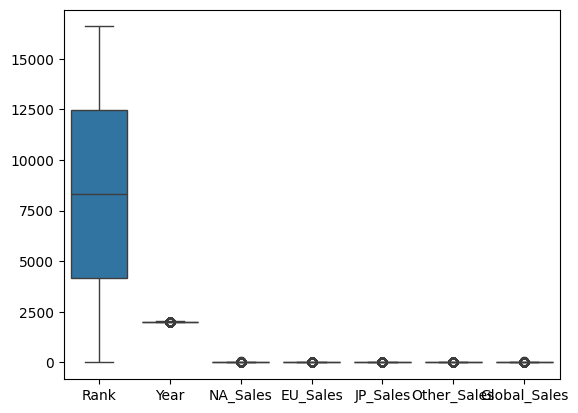

In [6]:
sns.boxplot(data=df1)

In [7]:
df1.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [8]:
df1.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [9]:
df1.drop_duplicates()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [10]:
df1['Publisher'].value_counts()

Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
                                ... 
Media Entertainment                1
New World Computing                1
Genterprise                        1
Rain Games                         1
UIG Entertainment                  1
Name: count, Length: 578, dtype: int64

In [11]:
df1['Publisher']=df1['Publisher'].fillna('Electronic Arts')

In [12]:
df1.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher         0
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [13]:
df1['Year'].value_counts()

Year
2009.0    1431
2008.0    1428
2010.0    1259
2007.0    1202
2011.0    1139
2006.0    1008
2005.0     941
2002.0     829
2003.0     775
2004.0     763
2012.0     657
2015.0     614
2014.0     582
2013.0     546
2001.0     482
1998.0     379
2000.0     349
2016.0     344
1999.0     338
1997.0     289
1996.0     263
1995.0     219
1994.0     121
1993.0      60
1981.0      46
1992.0      43
1991.0      41
1982.0      36
1986.0      21
1989.0      17
1983.0      17
1987.0      16
1990.0      16
1988.0      15
1985.0      14
1984.0      14
1980.0       9
2017.0       3
2020.0       1
Name: count, dtype: int64

In [14]:
df1['Year']=df1['Year'].fillna(2009.0)

In [15]:
df1['Year']=df1['Year'].astype(int)
df1['Year']=df1['Year'].astype(str)

In [16]:
df1.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [17]:
df1.to_csv('cleaned_vgsales.csv',index=False)

In [18]:
df2=pd.read_csv("games.csv")

In [19]:
df2.columns.value_counts().sum()

np.int64(14)

In [20]:
df2.isnull().sum()

Unnamed: 0            0
Title                 0
Release Date          0
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB


In [22]:
df2.shape

(1512, 14)

In [23]:
most_freq=df2['Release Date'].mode()[0]
most_freq
df2['Release Date']=df2['Release Date'].replace('releases on TBD',most_freq)

In [24]:
from sklearn.impute import SimpleImputer

In [25]:
SI=SimpleImputer(strategy='mean')
df2[['Rating']]=SI.fit_transform(df2[['Rating']])

In [26]:
SI1=SimpleImputer(strategy='most_frequent')
df2[['Team','Summary']]=SI1.fit_transform(df2[['Team','Summary']])

In [27]:
df2.isnull().sum()

Unnamed: 0           0
Title                0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

<Axes: >

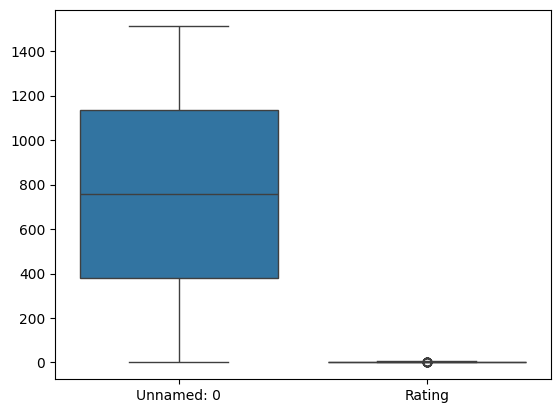

In [28]:
sns.boxplot(data=df2)

In [29]:
df2['Times Listed']=df2['Times Listed'].astype(str).str.replace('K','e3',regex=True)
df2['Times Listed'] = pd.to_numeric(df2['Times Listed'])
df2['Number of Reviews']=df2['Number of Reviews'].astype(str).str.replace('K','e3',regex=True)
df2['Number of Reviews'] = pd.to_numeric(df2['Number of Reviews'])
df2['Playing']=df2['Playing'].astype(str).str.replace('K','e3',regex=True)
df2['Playing'] = pd.to_numeric(df2['Playing'])
df2['Backlogs']=df2['Backlogs'].astype(str).str.replace('K','e3',regex=True)
df2['Backlogs'] = pd.to_numeric(df2['Backlogs'])
df2['Wishlist']=df2['Wishlist'].astype(str).str.replace('K','e3',regex=True)
df2['Wishlist'] = pd.to_numeric(df2['Wishlist'])
df2['Plays']=df2['Plays'].astype(str).str.replace('K','e3',regex=True)
df2['Plays'] = pd.to_numeric(df2['Plays'])


# print("\nDataFrame after processing:")

In [30]:
df2['Team']=df2['Team'].str.replace('[','')
df2['Team']=df2['Team'].str.replace(']','')
df2['Team']=df2['Team'].str.replace("'",'')

In [31]:
df2['Genres']=df2['Genres'].str.replace('[','')
df2['Genres']=df2['Genres'].str.replace(']','')
df2['Genres']=df2['Genres'].str.replace("'",'')

In [32]:
df2['Reviews']=df2['Reviews'].str.replace('[','')
df2['Reviews']=df2['Reviews'].str.replace(']','')
df2['Reviews']=df2['Reviews'].str.replace("'",'')

In [33]:
df2.drop('Summary',axis=1,inplace=True)

In [34]:
df2.drop(df2.columns[df2.columns.str.contains('Unnamed')],axis=1,inplace=True)

In [35]:
df2=df2.rename(columns={'Title':'Name'})

In [36]:
df2['Release Date']=pd.to_datetime(df2['Release Date'])
# df2['Release Date'].dtype

In [37]:
df2.to_csv('cleaned_games.csv',index=False)

In [38]:
df3=pd.read_csv("cleaned_vgsales.csv")
df4=pd.read_csv("cleaned_games.csv")


In [39]:
df3

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [40]:
merged_tables=pd.merge(df3,df4,on ='Name',how='inner')

In [41]:
merged_tables.to_csv("gamesales.csv")

In [42]:
df5=pd.read_csv("gamesales.csv")

In [43]:
df5.shape

(1344, 23)

In [44]:
df5.isnull().sum()

Unnamed: 0           0
Rank                 0
Name                 0
Platform             0
Year                 0
Genre                0
Publisher            0
NA_Sales             0
EU_Sales             0
JP_Sales             0
Other_Sales          0
Global_Sales         0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               1
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

In [45]:
df5.Genres.value_counts()

Genres
Adventure, RPG                                  147
Shooter                                         136
Adventure, Platform                             120
Adventure, Shooter                              103
Adventure, Brawler                               55
                                               ... 
Adventure, Indie, Point-and-Click, Puzzle         1
Arcade, Indie, Puzzle, Shooter                    1
Adventure, Indie, Platform, RPG                   1
Adventure, Indie, Platform, Puzzle, Strategy      1
Adventure, Indie, Simulator                       1
Name: count, Length: 106, dtype: int64

In [46]:
SI2=SimpleImputer(strategy='most_frequent')
df5[['Genres']]=SI2.fit_transform(df5[['Genres']])

In [47]:
df5.isnull().sum()

Unnamed: 0           0
Rank                 0
Name                 0
Platform             0
Year                 0
Genre                0
Publisher            0
NA_Sales             0
EU_Sales             0
JP_Sales             0
Other_Sales          0
Global_Sales         0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

In [48]:
df5.drop_duplicates(inplace=True)

In [49]:
df5.shape
# no duplicates

(1344, 23)

In [50]:
df5.drop(df5.columns[df5.columns.str.contains('Unnamed')],axis=1,inplace=True)

In [51]:
df5.shape
#Unknown column deleted

(1344, 22)

In [52]:
df5.to_csv("cleaned_merge.csv",index=False)

In [53]:
dfg=pd.read_csv("cleaned_games.csv")
dfs=pd.read_csv("cleaned_vgsales.csv")
dfm=pd.read_csv("cleaned_merge.csv")

<Axes: xlabel='Rating', ylabel='Name'>

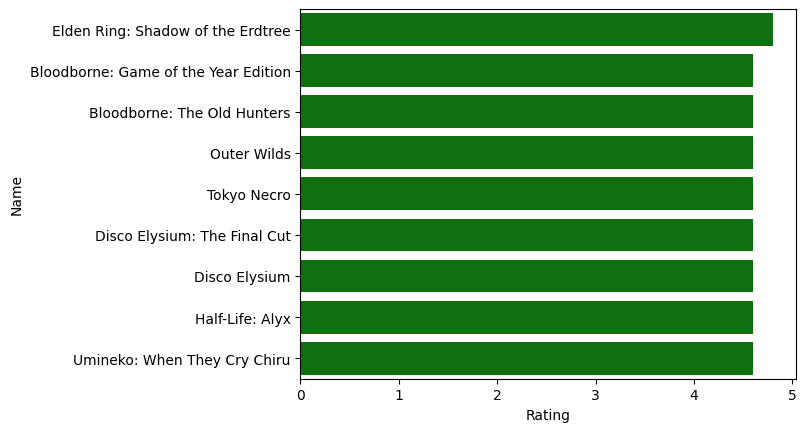

In [54]:
# 🌟 Q1: What are the top-rated games by user reviews?
top_rated=dfg.sort_values(by='Rating',ascending=False).head(10)
sns.barplot(x='Rating',y='Name',data=top_rated,color='g')


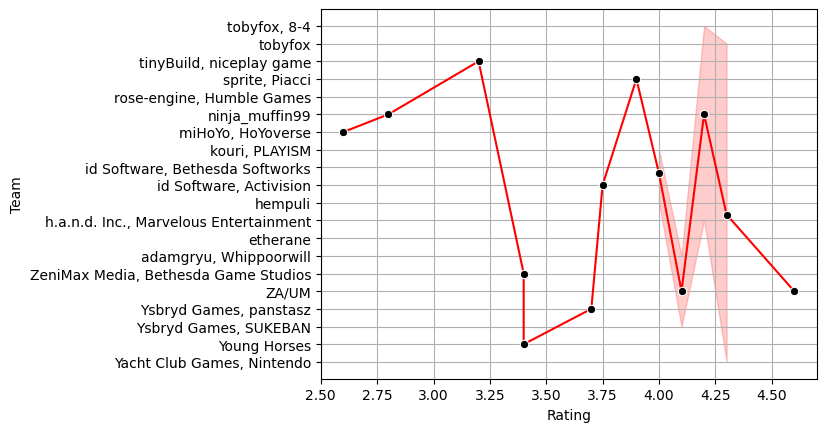

In [55]:
# Q2: Which developers (Teams) have the highest average ratings?
avrat=dfg.groupby('Team')[['Rating']].mean().sort_values(by='Team',ascending=False).head(20)
sns.lineplot(x='Rating',y='Team',data=avrat,marker='o',color='r',mfc='k')
plt.grid(axis='both')


<Axes: xlabel='count', ylabel='Genres'>

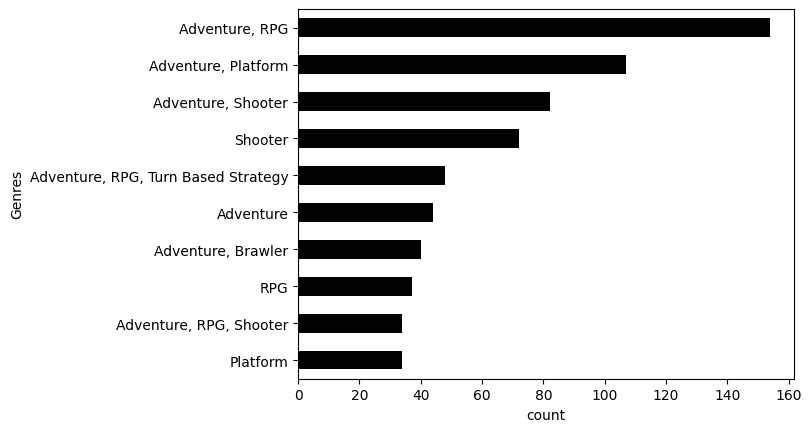

In [56]:
# Q3: 🧩 What are the most common genres in the dataset?
most_cmn=dfg['Genres'].value_counts(ascending=False).to_frame().head(10)
sns.barplot(x='count',y='Genres',data=most_cmn,width=0.5,color='k')

<Axes: xlabel='Name', ylabel='Backlogs'>

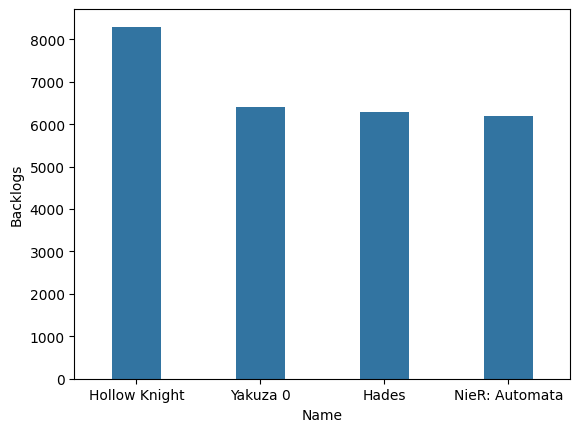

In [57]:
# Q4: ⏳ Which games have the highest backlog compared to wishlist?
bck=dfg[['Backlogs','Name']].sort_values(by='Backlogs',ascending=False).head(10)
sns.barplot(x='Name',y='Backlogs',data=bck,width=0.4)
# how to include wishlist
# 1 column backlog & other for wishlist

<Axes: xlabel='Year', ylabel='Name'>

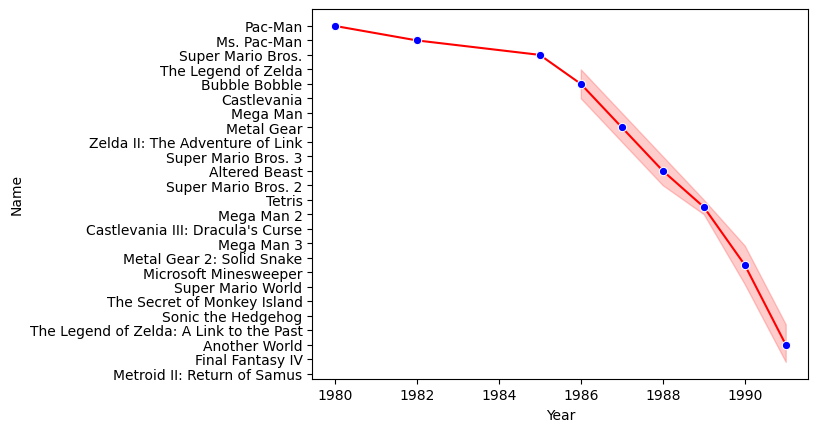

In [101]:
#Q5: 🗓️ What is the game release trend across years?

dfg['Release Date']=pd.to_datetime(dfg['Release Date'])
dfg['Year']=dfg['Release Date'].dt.year
trennd=dfg.groupby('Year')['Name'].value_counts().to_frame()
sns.lineplot(x='Year',y='Name',data=trennd.head(25),color='red',mfc='b',marker='o')


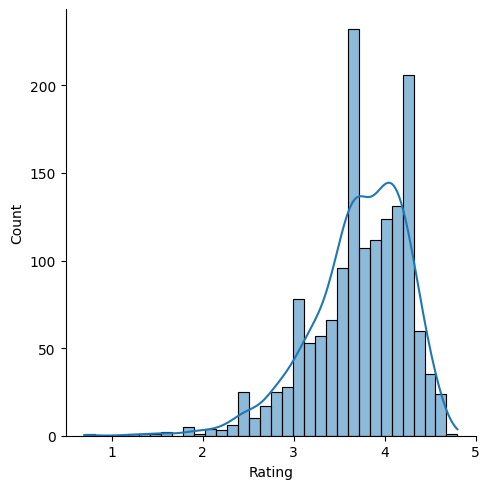

In [59]:
#Q6: 🔎 What is the distribution of user ratings?
sns.displot(dfg,x='Rating',kind='hist',kde=True)

<Axes: xlabel='Wishlist', ylabel='Name'>

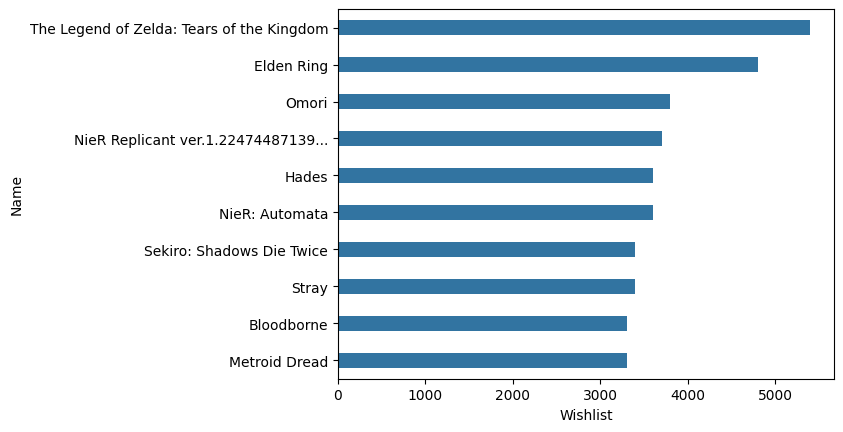

In [60]:
#Q7: 🧑 What are the top 10 most wishlisted games?
wishlist=dfg.sort_values(by='Wishlist',ascending=False).head(24)
# wishlist=wishlist.to_frame()
sns.barplot(x='Wishlist',y='Name',data=wishlist,width=0.4)


<Axes: xlabel='Plays', ylabel='Genres'>

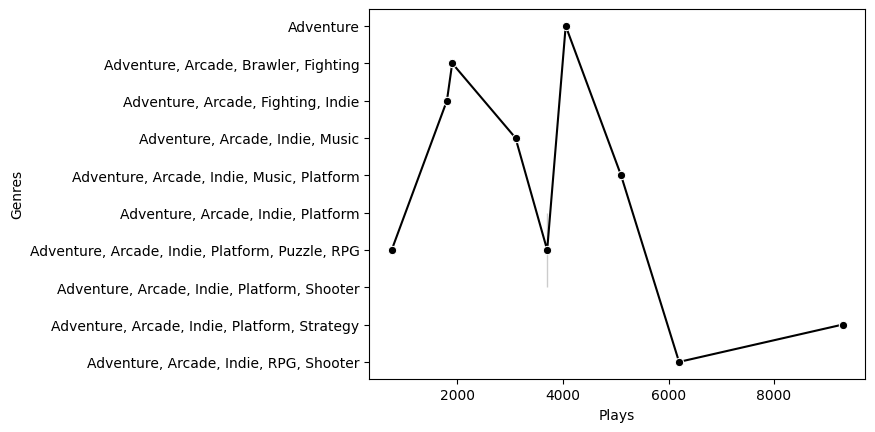

In [61]:
#Q8: 🔬 What’s the average number of plays per genre?
avg=dfg.groupby('Genres')[['Plays']].mean().head(10)
# avg=avg.head(10)
sns.lineplot(x='Plays',y='Genres',data=avg,color='k',marker='o')
# sns.boxplot(avg)

<Axes: xlabel='Plays', ylabel='Team'>

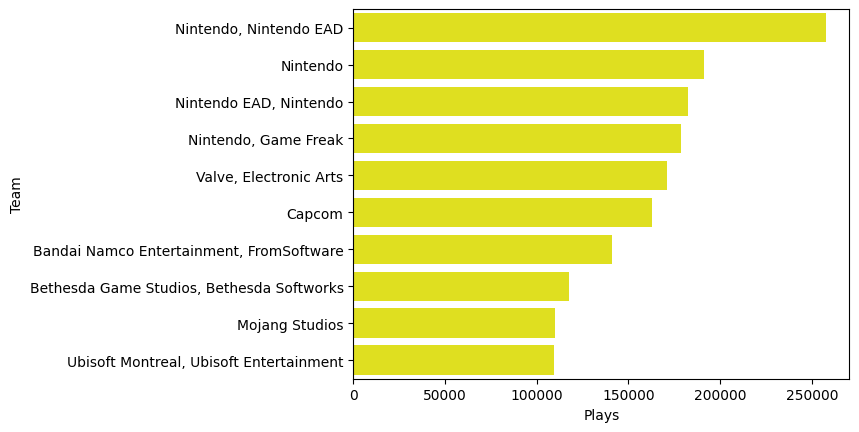

In [62]:
# Q9: 🏢 Which developer studios are the most productive and impactful?
prod=dfg.groupby('Team')['Plays'].sum().to_frame().sort_values(by='Plays',ascending=False).head(10)
sns.barplot(x='Plays',y='Team',data=prod,color='yellow')

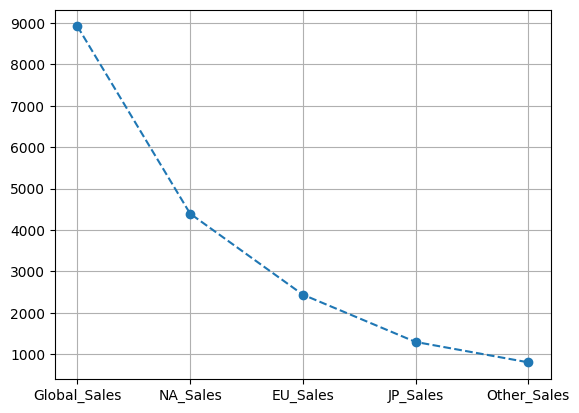

In [63]:
# Q10: Which region generates the most game sales?
gms=dfs[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].sum().sort_values(ascending=False).to_frame()
plt.plot(gms,ls='dashed',marker='o')
plt.grid(axis='both')

# no need of sorting

<Axes: xlabel='Total', ylabel='Platform'>

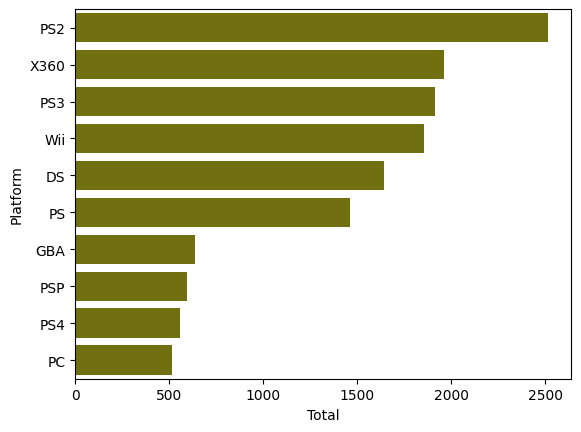

In [64]:
# Q11: 🕹️ What are the best-selling platforms?
dfs['Total']=dfs[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].sum(axis=1)
bst=dfs.groupby('Platform')['Total'].sum().sort_values(ascending=False).to_frame().head(10)
sns.barplot(x='Total',y='Platform',data=bst,color='olive')

<Axes: xlabel='Year', ylabel='Total'>

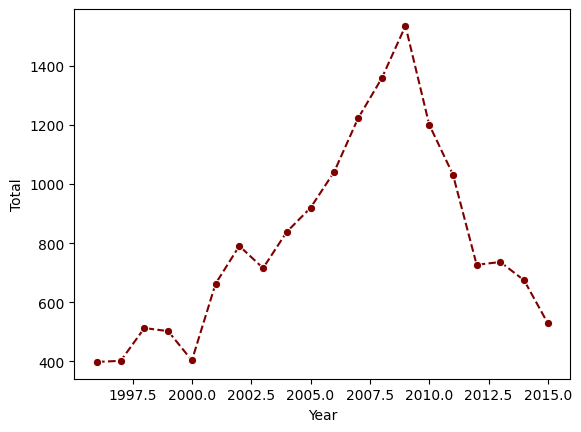

In [65]:
# Q12: 📅 What’s the trend of game releases and sales over years?
trend=dfs.groupby('Year')['Total'].sum().sort_values(ascending=False).to_frame().head(20)
sns.lineplot(x='Year',y='Total',data=trend,marker='o',ls='dashed',color='maroon')
# count of games over years, Global sales linechart for both release and sales

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Nintendo'),
  Text(1, 0, 'Microsoft Game Studios'),
  Text(2, 0, 'Activision'),
  Text(3, 0, 'Take-Two Interactive'),
  Text(4, 0, 'Atari'),
  Text(5, 0, 'Sony Computer Entertainment'),
  Text(6, 0, 'Ubisoft'),
  Text(7, 0, 'Electronic Arts'),
  Text(8, 0, 'Sega')])

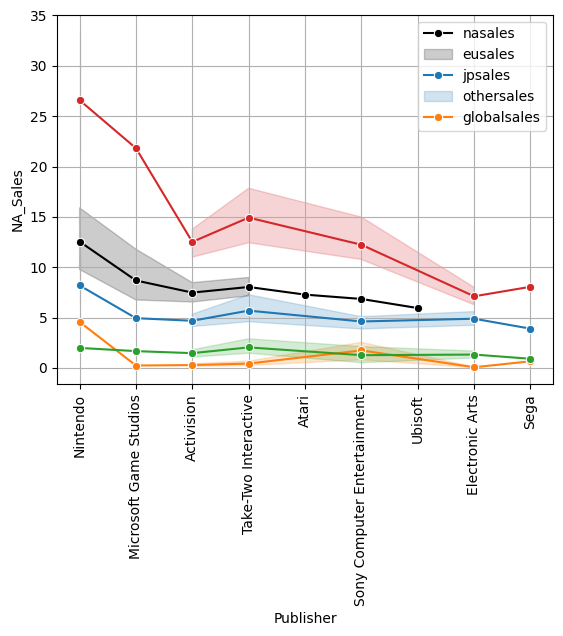

In [66]:
#Q13: 🏢 Who are the top publishers by sales?
nasales=dfs.sort_values(by='NA_Sales',ascending=False).head(50)
sns.lineplot(x='Publisher',y='NA_Sales',data=nasales,marker='o',color='k')
eusales=dfs.sort_values(by='EU_Sales',ascending=False).head(50)
sns.lineplot(x='Publisher',y='EU_Sales',data=eusales,marker='o')
jpsales=dfs.sort_values(by='JP_Sales',ascending=False).head(50)
sns.lineplot(x='Publisher',y='JP_Sales',data=eusales,marker='o')
othersales=dfs.sort_values(by='Other_Sales',ascending=False).head(50)
sns.lineplot(x='Publisher',y='Other_Sales',data=eusales,marker='o')
globalsales=dfs.sort_values(by='Global_Sales',ascending=False).head(50)
sns.lineplot(x='Publisher',y='Global_Sales',data=eusales,marker='o')
plt.legend(['nasales','eusales','jpsales','othersales','globalsales'],fontsize=10)
plt.grid(axis='both')
plt.xticks(rotation=90)


<Axes: xlabel='Global_Sales', ylabel='Name'>

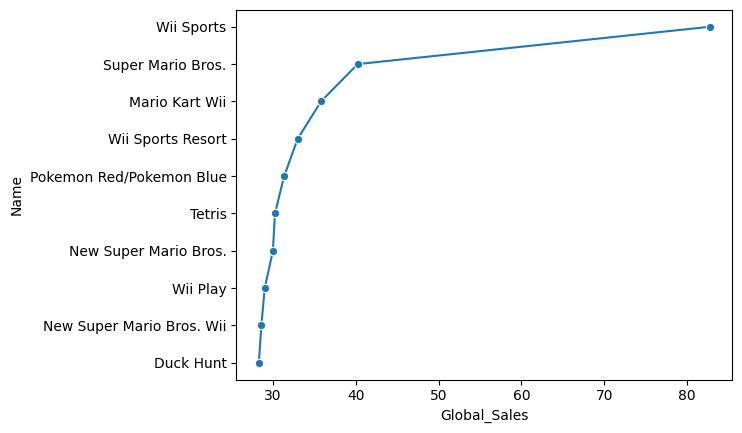

In [67]:
# Q14: 🔝 Which games are the top 10 best-sellers globally?
best=dfs.sort_values(by='Global_Sales',ascending=False).head(10)
sns.lineplot(x='Global_Sales',y='Name',data=best,marker='o',)

<Axes: xlabel='Platform', ylabel='Regional_Sales'>

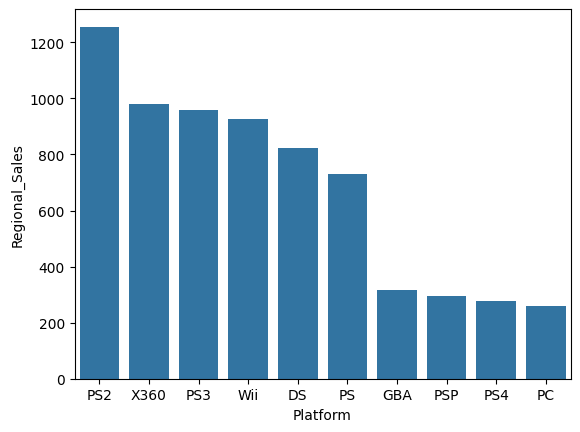

In [68]:
#Q15: How do regional sales compare for specific platforms?
dfs['Regional_Sales']=dfs[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum(axis=1)
reg_sales=dfs.groupby('Platform')['Regional_Sales'].sum().sort_values(ascending=False).to_frame().head(10)
sns.barplot(x='Platform',y='Regional_Sales',data=reg_sales)
# multiple barplot for different sales

<Figure size 1000x600 with 0 Axes>

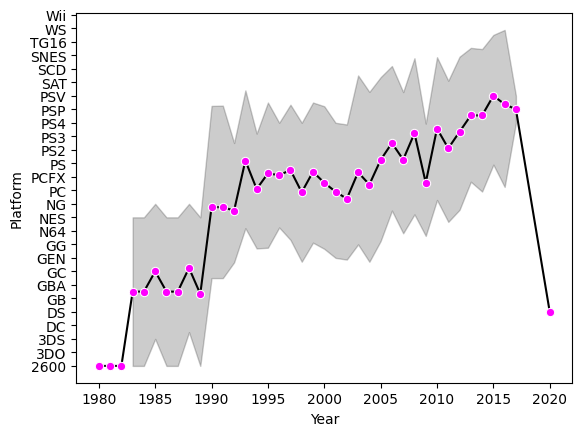

<Figure size 1000x600 with 0 Axes>

In [69]:
# Q16: How has the market evolved by platform over time?
market=dfs.groupby('Year')[['Platform']].value_counts().to_frame().sort_values(by='Platform',ascending=False)
sns.lineplot(x='Year',y='Platform',data=market,color='k',mfc='magenta',marker='o')
plt.figure(figsize=(10,6))

<Axes: xlabel='Regional_Sales', ylabel='Genre'>

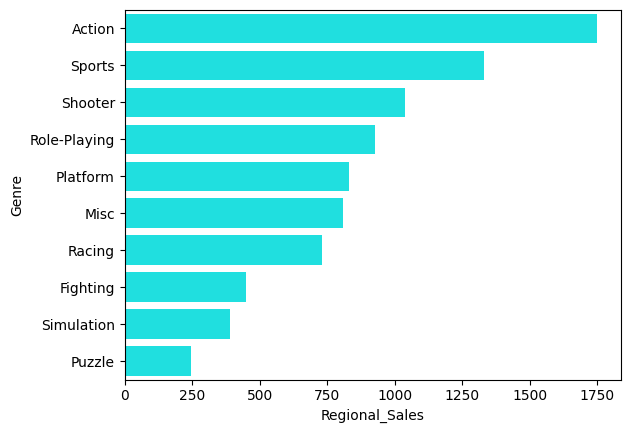

In [70]:
#Q17:  What are the regional genre preferences?
pref=dfs.groupby('Genre')[['Regional_Sales']].sum().sort_values(by='Regional_Sales',ascending=False).head(10)
sns.barplot(x='Regional_Sales',y='Genre',data=pref,color='cyan')

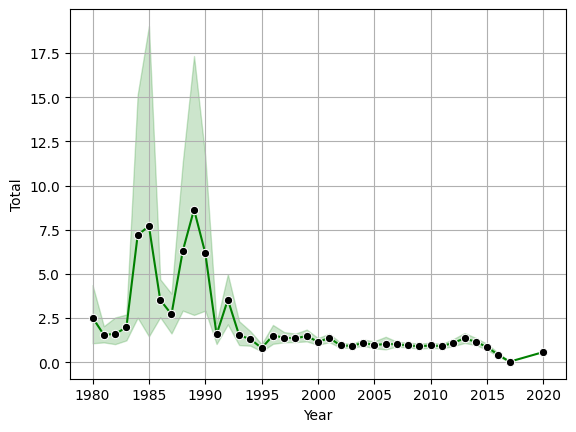

In [71]:
# Q18:What’s the yearly sales change per region?
sns.lineplot(x='Year',y='Total',data=dfs,marker='o',color='g',mfc='k')
plt.grid(axis='both')
# dfs.head()

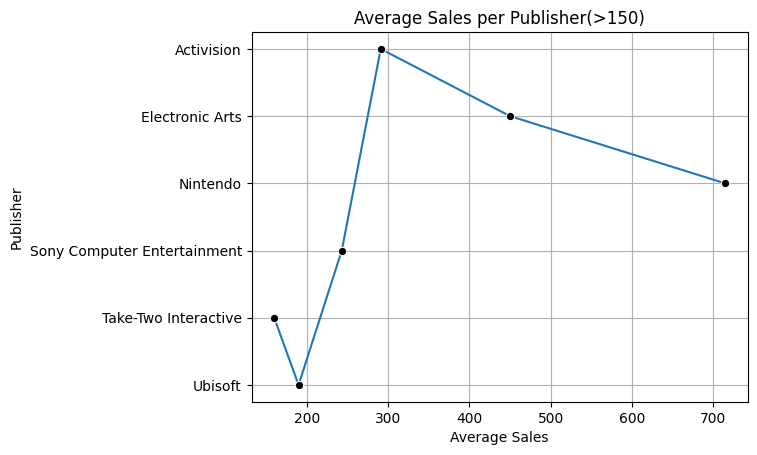

In [83]:
# Q19: 🧮 What is the average sales per publisher?
dfs[['Avg_Sales']]=dfs[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].mean(axis=1).to_frame()
avg_sales=dfs.groupby('Publisher')['Avg_Sales'].sum().to_frame()
avg_sales_sort=avg_sales[avg_sales['Avg_Sales']>150]
# .sort_values(by='Avg_Sales',ascending=False)
# plt.figure(figsize=(10,6))
sns.lineplot(x='Avg_Sales',y='Publisher',data=avg_sales_sort,marker='o',mfc='k')
plt.title('Average Sales per Publisher(>150)')
plt.xlabel('Average Sales')
plt.ylabel('Publisher')
plt.grid(axis='both')
plt.show()




<Axes: xlabel='Platform', ylabel='Total'>

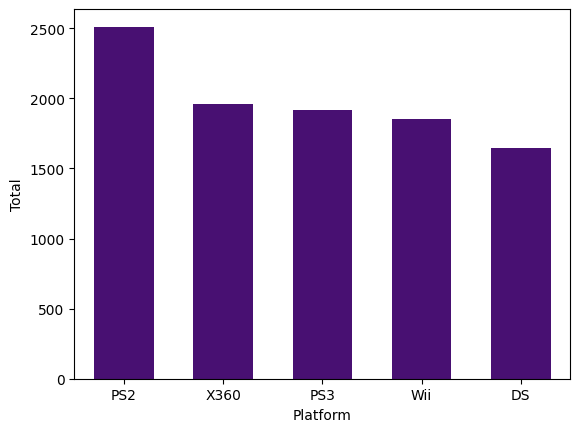

In [73]:
# Q20:  What are the top 5 best-selling games per platform?
best_sell=dfs.groupby('Platform')['Total'].sum().sort_values(ascending=False).to_frame().head()
sns.barplot(x='Platform',y='Total',data=best_sell,width=0.6,color='indigo')

<Axes: xlabel='Global_Sales', ylabel='Genres'>

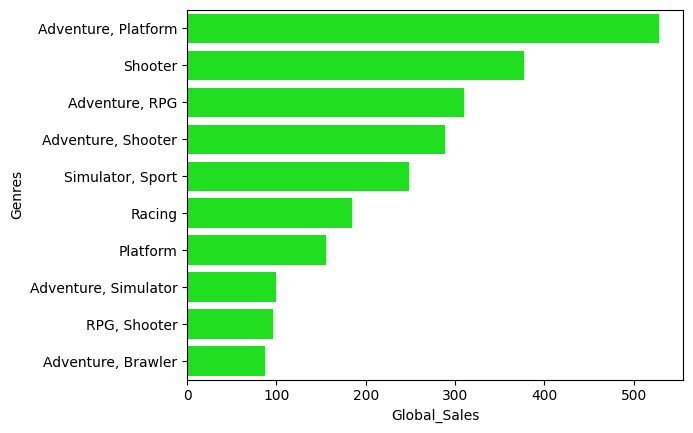

In [74]:
# 21🎮 Which game genres generate the most global sales?
most_sales=dfm.groupby('Genres')[['Global_Sales']].sum().sort_values(by='Global_Sales',ascending=False).head(10)
sns.barplot(x='Global_Sales',y='Genres',data=most_sales,color='lime')

<Axes: xlabel='Rating', ylabel='Global_Sales'>

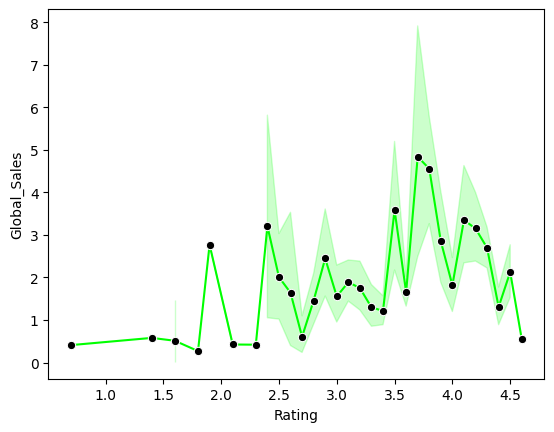

In [75]:
# Q22: 🎯 How does user rating affect global sales?
sns.lineplot(x='Rating',y='Global_Sales',data=dfm, marker='o', color='lime',mfc='black')


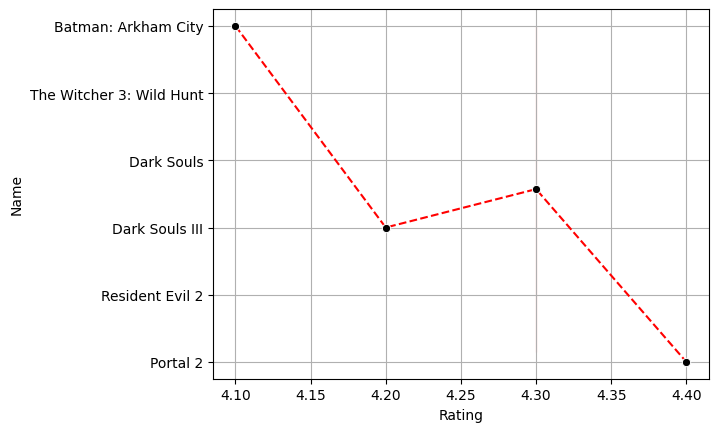

In [76]:
# Q23: 🕹️ Which platforms have the most games with high ratings (e.g., above 4)?
dfm.head()
rat=dfm.loc[dfm['Rating']>4]

rating=rat.groupby('Rating')[['Name']].value_counts().sort_values(ascending=False).to_frame().head(10)
sns.lineplot(x='Rating',y='Name',data=rating,marker='o',ls='dashed',color='red',mfc='black')
plt.grid(axis='both')


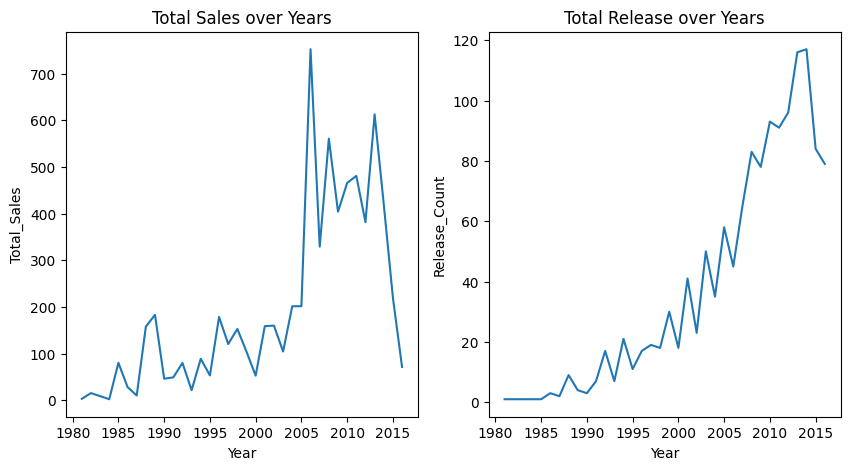

In [98]:
# Q24:📈 What’s the trend of releases and sales over time?

rel_time=dfm.groupby('Year')['Total_Sales'].sum().reset_index()
sales_time=dfm.groupby('Year')['Release Date'].count().reset_index(name='Release_Count')
fig,axs=plt.subplots(1,2,figsize=(10,5))
sns.lineplot(data=rel_time,x='Year',y='Total_Sales',ax=axs[0])
axs[0].set_title('Total Sales over Years')
sns.lineplot(data=sales_time,x='Year',y='Release_Count',ax=axs[1])
axs[1].set_title('Total Release over Years')

plt.tight_layout
plt.show()


<Axes: xlabel='Wishlist', ylabel='Global_Sales'>

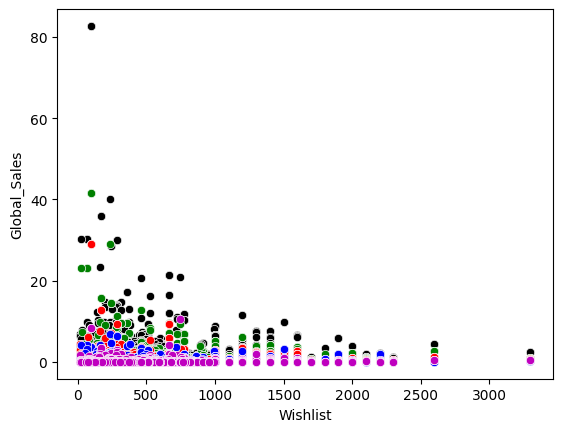

In [ ]:
# Q25: 🧍 Do highly wishlisted games lead to more sales?

sns.scatterplot(x='Wishlist',y='Global_Sales',data=dfm,color='k',marker='o')
sns.scatterplot(x='Wishlist',y='NA_Sales',data=dfm,color='g',marker='o')
sns.scatterplot(x='Wishlist',y='EU_Sales',data=dfm,color='r',marker='o')
sns.scatterplot(x='Wishlist',y='JP_Sales',data=dfm,color='b',marker='o')
sns.scatterplot(x='Wishlist',y='Other_Sales',data=dfm,color='m',marker='o')

# plt.show()

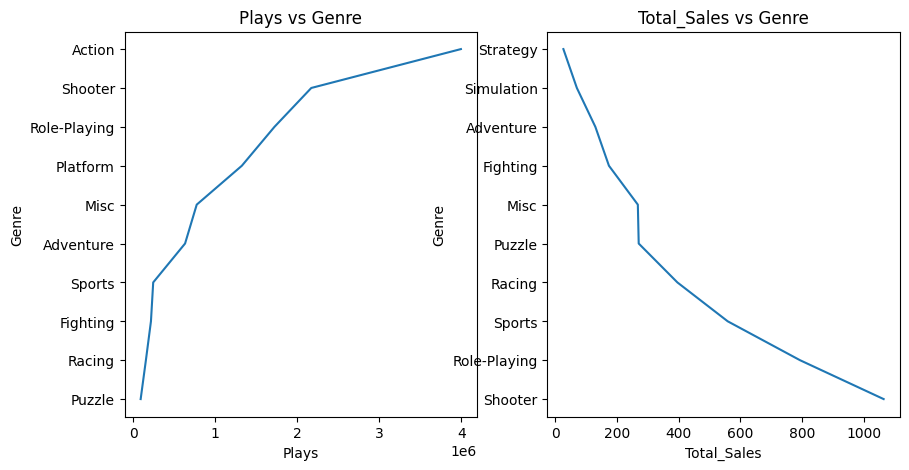

In [ ]:
# Q26: 🎮 Which genres have the highest engagement but lowest sales?
engage=dfm.groupby('Genre')[['Plays']].sum().sort_values(by='Plays',ascending=False).head(10)
# sns.lineplot(x='Plays',y='Genre',data=engage,marker='o',color='k')
sales_genre=dfm.groupby('Genre')[['Total_Sales']].sum().sort_values(by='Total_Sales',ascending=True).head(10)
# sns.lineplot(x='Total_Sales',y='Genre',data=sales_genre,marker='o',color='k')
# eusales=dfs.soralues(by='EU_Sales',ascending=False).head(50)
# sns.lineplot(x='Publisher',y='EU_Sales',data=eusales,marker='o')
# jpsales=dfs.sort_values(by='JP_Sales',ascending=False).head(50)
fig,axs=plt.subplots(1,2,figsize=(10,5))
sns.lineplot(data=engage,x='Plays',y='Genre',ax=axs[0])
axs[0].set_title('Plays vs Genre')
sns.lineplot(data=sales_genre,x='Total_Sales',y='Genre',ax=axs[1])
axs[1].set_title('Total_Sales vs Genre')

plt.tight_layout
plt.show()

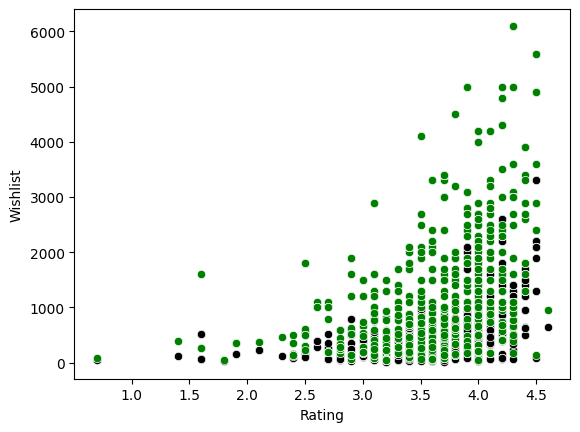

<Axes: >

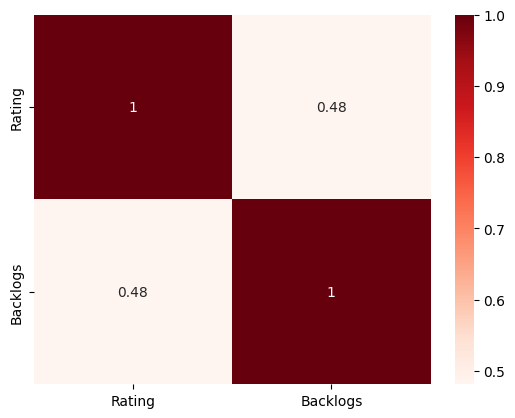

In [ ]:

#Q27: 🧠 Do highly listed games (wishlist/backlogs) correlate with better ratings?
sns.scatterplot(data=dfm,x='Rating',y='Wishlist',c='k')
sns.scatterplot(data=dfm,x='Rating',y='Backlogs',c='g')
plt.show()

corr = dfm[['Rating','Backlogs']].corr(numeric_only=True)
sns.heatmap(corr,cmap='Reds',annot=True)


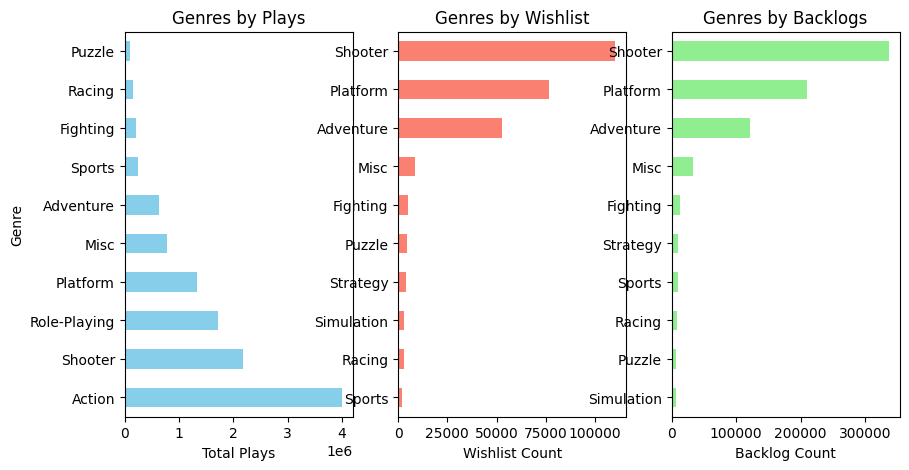

In [ ]:
# Q28: 🏷️ How does user engagement differ across genres?

engg=dfm.groupby('Genre')[['Plays']].sum().sort_values(by='Plays',ascending=False).head(10)
wish=dfm.groupby('Genre')[['Wishlist']].sum().sort_values(by='Wishlist',ascending=True).head(10)
backlog=dfm.groupby('Genre')[['Backlogs']].sum().sort_values(by='Backlogs',ascending=True).head(10)
fig,axs=plt.subplots(1,3,figsize=(10,5))
# sns.lineplot(data=engg,x='Plays',y='Genre',ax=axs[0])
# axs[0].set_title('Genre vs Plays')
# sns.lineplot(data=wish,x='Wishlist',y='Genre',ax=axs[1])
# axs[1].set_title('Genre vs Wishlist')
# sns.lineplot(data=backlog,x='Backlogs',y='Genre',ax=axs[2])
# axs[2].set_title('Genre vs Backlogs')

engg.plot(kind='barh',ax=axs[0],color='skyblue',legend=False)
wish.plot(kind='barh',ax=axs[1],color='salmon',legend=False)
backlog.plot(kind='barh',ax=axs[2],color='lightgreen',legend=False)

axs[0].set_title('Genres by Plays')
axs[0].set_xlabel('Total Plays')
axs[0].set_ylabel('Genre')
axs[1].set_title('Genres by Wishlist')
axs[1].set_xlabel('Wishlist Count')
axs[1].set_ylabel('') 
axs[2].set_title('Genres by Backlogs')
axs[2].set_xlabel('Backlog Count')
axs[2].set_ylabel('')

plt.tight_layout
plt.show()

# dfm.head()

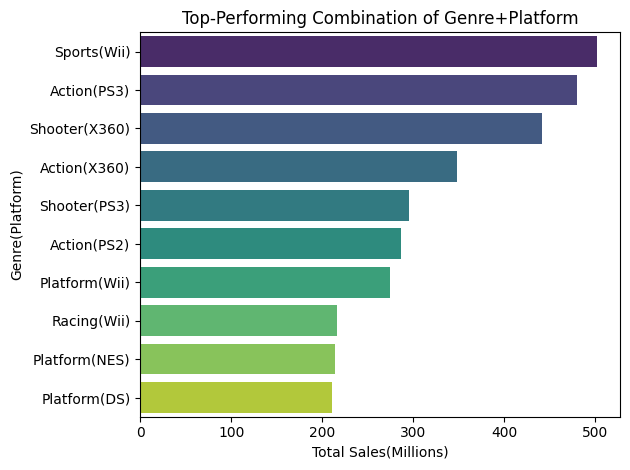

In [82]:
# Q29: 🎉 What are the top-performing combinations of Genre + Platform?
# dfm.head(5)
# group by genre, platform and check sales_genre
# which is giving higher sales
dfm[['Total_Sales']]=dfm[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].sum(axis=1).to_frame()
top_perform=dfm.groupby(['Genre','Platform'])['Total_Sales'].sum().reset_index().sort_values(by='Total_Sales',ascending=False)
# sns.barplot(data=top_perform,x='Total_Sales',y=['Genre','Platform'])
top_perform['Genre_Platform']=top_perform['Genre']+"("+top_perform['Platform']+")"

# plt.figure(figsize=(10,6))
sns.barplot(data=top_perform.head(10),x='Total_Sales',y='Genre_Platform',legend=False,palette='viridis',hue='Genre_Platform')
# palette='viridis'
plt.title('Top-Performing Combination of Genre+Platform')
plt.xlabel('Total Sales(Millions)')
plt.ylabel('Genre(Platform)')
plt.tight_layout()
plt.show()

<Axes: >

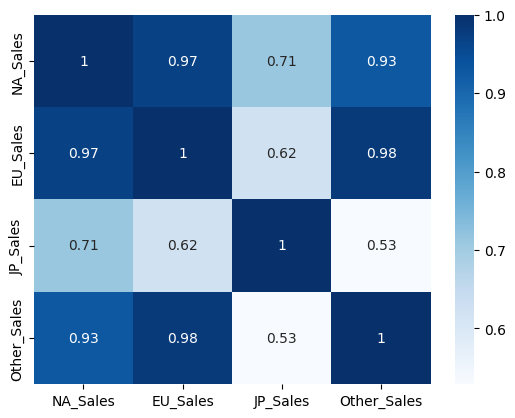

In [107]:
# Q30: 🌐 What does a regional sales heatmap by genre reveal?
region=dfm.groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
corr = region.corr(numeric_only=True)
sns.heatmap(corr,cmap='Blues',annot=True)